<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

# Sistemas de Recomendación

Este proyecto tiene como objetivo construir un modelo de clasificación supervisado que, basándose en datos demográficos y socioeconómicos de un adulto (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si la persona ganará más o menos de $50,000 al año.

A partir de los resultados del modelo, los estudiantes deben desarrollar un sistema de recomendación interpretativo capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

## Objetivos
Explorar datos censales.
Construir perfiles socioeconómicos.
Analizar la importancia y el peso de las variables sociales (educación, género, raza, etc.) en las predicciones económicas.
Aplicar técnicas de sistemas de recomendación.
Visualizar y comunicar hallazgos de manera profesional.

</div>

In [16]:
%pip install nltk --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:

# CONFIGURACIÓN DEL ENTORNO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Librerías para gestionar archivos
from pathlib import Path
import os

# Librerías para gestionar imágenes
from PIL import Image

# Librerías para aprendizaje automático
from sklearn.svm import SVC
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from pickle import dump
from pathlib import Path

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")

✓ ¡Librerías importadas exitosamente!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Paso 1: Carga del conjunto de datos
Carga el conjunto de datos. Utilizaremos el **Adult Income Dataset**, también conocido como "Census Income". Esta información fue recopilada por la Oficina del Censo de EE.UU. y descargada por la academia para almacenarla en la carpeta de este proyecto bajo el nombre adult-census-income.csv. Alternativamente, puedes cargarlo directamente en tu código desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=2325&path=adult-census-income.csv
Este conjunto de datos incluye variables como:

- Edad
- Nivel educativo
- Estado civil
- Ocupación
- Horas trabajadas por semana
- Género
- País de origen
- Ingreso anual (>50K o <=50K)

**Preprocesamiento de datos** Limpia datos nulos o mal codificados, transforma variables categóricas y normaliza variables numéricas.

**Definir el problema de recomendación** Planifica cómo estructurarás tu sistema de recomendación:

¿Qué se recomienda?
¿Quién es el "usuario" en este caso?
¿Qué variables definen el perfil de un usuario?
Construir el sistema de recomendación. Usa uno de los siguientes enfoques:

Filtrado basado en contenido. Representa cada usuario como un vector y calcula similitudes entre usuarios y recomendaciones.

Filtrado colaborativo. Simula una matriz de usuario vs. trayectoria. Aplica k-NN, correlación de Pearson o factorización de matrices.

Sistema híbrido. Combina ambos enfoques.

Probar con casos simulados. Construye perfiles simulados de usuarios hipotéticos y observa qué trayectorias (educación, ocupación, etc.) el sistema recomendaría para mejorar su ingreso estimado.

</div>

In [18]:
# Cargar datos preprocesados
df = pd.read_csv('../data/raw/adult-census-income.csv')
print(df.head(10))
print(f"\nForma: {df.shape}")
print(f"\nTipos de columnas:\n{df.dtypes}")

   age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-managerial   Not-in-family

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Paso 2: Preprocesamiento de datos

Limpiar datos nulos/mal codificados — Reemplaza los marcadores '?' con NaN, elimina espacios en blanco de las columnas de texto, y luego descarta filas con valores faltantes (~7% de los datos).

Transformar variables categóricas — Codifica la variable objetivo (ingreso) como binaria (0/1), luego aplica codificación one-hot (pd.get_dummies) a todas las demás columnas categóricas (workclass, education, marital.status, occupation, relationship, race, sex, native.country).

Normalizar variables numéricas — Aplica MinMaxScaler para escalar todas las columnas numéricas (age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week) al rango [0, 1].

</div>

In [19]:
## ============================================================
## Paso 2: Preprocesamiento de Datos
## ============================================================

# --- 2.1 Inspección inicial ---
print("=== RESUMEN INICIAL DE LOS DATOS ===")
print(f"Forma: {df.shape}")
print(f"\nTipos de columnas:\n{df.dtypes}")
print(f"\nPrimeras filas:\n{df.head()}")

# --- 2.2 Limpiar datos nulos y mal codificados ---
# El dataset usa '?' para representar valores faltantes — reemplazar con NaN
df.replace('?', np.nan, inplace=True)

# Eliminar espacios en blanco al inicio/final de columnas de texto
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print("\n=== VALORES FALTANTES DESPUÉS DE REEMPLAZAR '?' ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal de filas con al menos un NaN: {df.isnull().any(axis=1).sum()} / {len(df)}")

# Eliminar filas con valores faltantes (representan ~7% de los datos)
df_clean = df.dropna().reset_index(drop=True)
print(f"\nForma después de eliminar filas con NaN: {df_clean.shape}")

# --- 2.3 Transformar variables categóricas ---
# Identificar columnas categóricas y numéricas
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
numerical_cols = df_clean.select_dtypes(include='number').columns.tolist()

print(f"\n=== CLASIFICACIÓN DE COLUMNAS ===")
print(f"Categóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"Numéricas ({len(numerical_cols)}): {numerical_cols}")

# Codificar la variable objetivo (ingreso)
df_clean['income_binary'] = (df_clean['income'] == '>50K').astype(int)

# Codificación one-hot de características categóricas (excluyendo la variable objetivo 'income')
cat_features = [c for c in categorical_cols if c != 'income']
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=True, dtype=int)

# Eliminar la columna original 'income' de texto
df_encoded.drop(columns=['income'], inplace=True)

print(f"\nForma después de la codificación: {df_encoded.shape}")
print(f"Muestra de columnas codificadas: {df_encoded.columns[:15].tolist()} ...")

# --- 2.4 Normalizar variables numéricas ---
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print(f"\n=== COLUMNAS NUMÉRICAS DESPUÉS DE NORMALIZACIÓN (MinMaxScaler) ===")
print(df_encoded[numerical_cols].describe().round(3))

# --- 2.5 Dataset preprocesado final ---
print(f"\n=== DATASET PREPROCESADO FINAL ===")
print(f"Forma: {df_encoded.shape}")
print(f"Distribución de la variable objetivo:\n{df_encoded['income_binary'].value_counts()}")
print(f"\nVista previa:")
df_encoded.head()

=== RESUMEN INICIAL DE LOS DATOS ===
Forma: (32561, 15)

Tipos de columnas:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Primeras filas:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,0.890411,0.080970,0.533333,0.0,1.000000,0.173469,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0.506849,0.086061,0.200000,0.0,0.895317,0.397959,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,0.328767,0.170568,0.600000,0.0,0.895317,0.397959,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0.232877,0.138072,0.533333,0.0,0.865473,0.448980,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,0.287671,0.093024,0.333333,0.0,0.865473,0.397959,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Paso 3: Definir el Problema de Recomendación

### ¿Qué se recomienda?
**Trayectorias profesionales/de vida** (combinaciones de nivel educativo, ocupación, estado civil, horas trabajadas, etc.) que están estadísticamente asociadas con ganar **>50K/año**. Es decir, recomendamos *cambios socioeconómicos accionables* que una persona podría perseguir para aumentar su probabilidad de superar el umbral de ingresos de $50,000.

### ¿Quién es el "usuario"?
Cada fila en el dataset representa un **individuo adulto** caracterizado por su perfil demográfico y socioeconómico. Un "usuario" es cualquier persona (real o simulada) cuyo perfil actual lo coloca en la categoría de ingresos **<=50K** y que desea orientación sobre cómo moverse hacia la categoría **>50K**.

### ¿Qué variables definen el perfil de un usuario?
El perfil se define por dos grupos de características:

| Tipo | Variables | Rol |
|------|-----------|------|
| **Fijas/difíciles de cambiar** | age, race, sex, native.country | Contexto — se usan para encontrar usuarios similares pero NO se recomienda cambiarlas |
| **Accionables/modificables** | education, occupation, marital.status, hours.per.week, workclass, relationship | Objetivos de recomendación — estas son las palancas que un usuario puede potencialmente ajustar |

### Enfoque del sistema
Utilizaremos una estrategia de **filtrado basado en contenido**:
1. Representar a cada persona como un vector de características (ya hecho mediante codificación one-hot + normalización).
2. Identificar **perfiles exitosos** (ingreso >50K).
3. Para un perfil de usuario dado (<=50K), encontrar los perfiles exitosos más similares usando similitud coseno.
4. Analizar qué difiere entre el perfil actual del usuario y esos vecinos exitosos — esas diferencias se convierten en las **recomendaciones**.

</div>

In [20]:
## ============================================================
## Paso 3: Estructurar el Problema de Recomendación
## ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# --- 3.1 Definir grupos de variables del perfil ---
fixed_vars = ['age', 'race', 'sex', 'native.country']
actionable_vars = ['education', 'occupation', 'marital.status', 
                   'hours.per.week', 'workclass', 'relationship']

print("=== DEFINICIÓN DEL PROBLEMA DE RECOMENDACIÓN ===\n")
print("QUÉ se recomienda: Cambios de trayectoria profesional/vital para aumentar la probabilidad de ingresos")
print("QUIÉN es el usuario: Un adulto que actualmente gana <=50K")
print(f"\nVariables del perfil ({len(fixed_vars)} fijas + {len(actionable_vars)} accionables):")
print(f"  Fijas (contexto):        {fixed_vars}")
print(f"  Accionables (palancas):  {actionable_vars}")

# --- 3.2 Dividir en perfiles exitosos vs. no exitosos ---
successful = df_encoded[df_encoded['income_binary'] == 1].copy()
unsuccessful = df_encoded[df_encoded['income_binary'] == 0].copy()

print(f"\n=== DIVISIÓN DE PERFILES ===")
print(f"Perfiles exitosos (>50K):    {len(successful)} ({100*len(successful)/len(df_encoded):.1f}%)")
print(f"Perfiles no exitosos (<=50K): {len(unsuccessful)} ({100*len(unsuccessful)/len(df_encoded):.1f}%)")

# --- 3.3 Identificar columnas accionables codificadas ---
# Estas son las columnas codificadas one-hot que se originaron de las variables accionables
actionable_encoded_cols = [col for col in df_encoded.columns 
                           if any(col.startswith(v + '_') for v in actionable_vars) 
                           or col in ['hours.per.week']]

fixed_encoded_cols = [col for col in df_encoded.columns 
                      if any(col.startswith(v + '_') for v in fixed_vars)
                      or col in ['age']]

print(f"\n=== CONTEO DE CARACTERÍSTICAS CODIFICADAS ===")
print(f"Características accionables codificadas: {len(actionable_encoded_cols)}")
print(f"Características fijas codificadas:       {len(fixed_encoded_cols)}")

# --- 3.4 Demostrar el cálculo de similitud ---
# Seleccionar un "usuario" de muestra del grupo no exitoso
sample_user = unsuccessful.iloc[[0]]
feature_cols = [c for c in df_encoded.columns if c != 'income_binary']

# Calcular similitud coseno entre el usuario de muestra y todos los perfiles exitosos
similarities = cosine_similarity(sample_user[feature_cols], successful[feature_cols])[0]

# Encontrar los 5 perfiles exitosos más similares
top_k = 5
top_indices = similarities.argsort()[-top_k:][::-1]

print(f"\n=== RECOMENDACIÓN DE EJEMPLO (Usuario #0 del grupo <=50K) ===")
print(f"Top-{top_k} perfiles exitosos más similares (similitud coseno):")
for rank, idx in enumerate(top_indices, 1):
    print(f"  #{rank}: Similitud = {similarities[idx]:.4f}")

# Mostrar qué características accionables difieren
print(f"\n--- Diferencias accionables clave con la mejor coincidencia ---")
best_match = successful.iloc[top_indices[0]]
user_profile = sample_user.iloc[0]

differences = {}
for col in actionable_encoded_cols:
    if user_profile[col] != best_match[col]:
        differences[col] = {'user': user_profile[col], 'recommended': best_match[col]}

# Mostrar las principales diferencias (limitado a las más relevantes)
diff_df = pd.DataFrame(differences).T
diff_df.columns = ['Actual (Usuario)', 'Recomendado (Coincidencia)']
print(diff_df[diff_df['Recomendado (Coincidencia)'] == 1].head(10))
print(f"\nTotal de diferencias en características accionables: {len(differences)}")

=== DEFINICIÓN DEL PROBLEMA DE RECOMENDACIÓN ===

QUÉ se recomienda: Cambios de trayectoria profesional/vital para aumentar la probabilidad de ingresos
QUIÉN es el usuario: Un adulto que actualmente gana <=50K

Variables del perfil (4 fijas + 6 accionables):
  Fijas (contexto):        ['age', 'race', 'sex', 'native.country']
  Accionables (palancas):  ['education', 'occupation', 'marital.status', 'hours.per.week', 'workclass', 'relationship']

=== DIVISIÓN DE PERFILES ===
Perfiles exitosos (>50K):    7508 (24.9%)
Perfiles no exitosos (<=50K): 22654 (75.1%)

=== CONTEO DE CARACTERÍSTICAS CODIFICADAS ===
Características accionables codificadas: 46
Características fijas codificadas:       46

=== RECOMENDACIÓN DE EJEMPLO (Usuario #0 del grupo <=50K) ===
Top-5 perfiles exitosos más similares (similitud coseno):
  #1: Similitud = 0.9411
  #2: Similitud = 0.9151
  #3: Similitud = 0.8780
  #4: Similitud = 0.8737
  #5: Similitud = 0.8648

--- Diferencias accionables clave con la mejor coincide

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Paso 4: Construir el Sistema de Recomendación (Enfoque Híbrido)

Implementamos un **sistema híbrido** que combina:

1. **Filtrado basado en contenido** — Representa cada usuario como un vector de características y usa similitud coseno para encontrar los perfiles exitosos más similares (personas que ganan >50K).

2. **Filtrado colaborativo (k-NN)** — Usa k-Vecinos Más Cercanos en el espacio "usuario × trayectoria" para encontrar grupos de usuarios similares e identificar las trayectorias más comunes entre los vecinos exitosos.

El motor híbrido:
- Usa similitud basada en contenido para encontrar perfiles exitosos candidatos
- Usa lógica colaborativa k-NN para agregar recomendaciones de múltiples vecinos
- Produce recomendaciones interpretables y accionables clasificadas por frecuencia e impacto

</div>

In [21]:
## ============================================================
## Paso 4: Construir el Sistema de Recomendación Híbrido
## ============================================================

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from collections import Counter

# --- 4.1 Preparar estructuras de datos ---
feature_cols = [c for c in df_encoded.columns if c != 'income_binary']

successful = df_encoded[df_encoded['income_binary'] == 1].reset_index(drop=True)
unsuccessful = df_encoded[df_encoded['income_binary'] == 0].reset_index(drop=True)

# Identificar columnas accionables codificadas (de education, occupation, marital.status, etc.)
actionable_vars = ['education', 'occupation', 'marital.status', 
                   'hours.per.week', 'workclass', 'relationship']

actionable_encoded_cols = [col for col in df_encoded.columns 
                           if any(col.startswith(v + '_') for v in actionable_vars) 
                           or col in ['hours.per.week']]

print(f"Espacio de características: {len(feature_cols)} dimensiones")
print(f"Características accionables: {len(actionable_encoded_cols)}")
print(f"Pool exitoso: {len(successful)} perfiles")
print(f"Usuarios para recomendar: {len(unsuccessful)} perfiles")


# ============================================================
# 4.2 MOTOR DE FILTRADO BASADO EN CONTENIDO
# ============================================================

def content_based_recommendations(user_vector, successful_pool, feature_cols, 
                                   actionable_cols, top_k=10):
    """
    Encontrar los Top-K perfiles exitosos más similares al usuario
    y extraer diferencias accionables como recomendaciones.
    """
    # Calcular similitud coseno
    sims = cosine_similarity(
        user_vector[feature_cols].values.reshape(1, -1),
        successful_pool[feature_cols].values
    )[0]
    
    # Obtener los índices Top-K
    top_indices = sims.argsort()[-top_k:][::-1]
    top_similarities = sims[top_indices]
    
    # Extraer recomendaciones de las diferencias accionables
    recommendations = []
    for idx, sim in zip(top_indices, top_similarities):
        neighbor = successful_pool.iloc[idx]
        for col in actionable_cols:
            user_val = user_vector[col]
            neighbor_val = neighbor[col]
            # Recomendar características que el vecino TIENE y el usuario NO
            if neighbor_val == 1 and user_val == 0:
                recommendations.append({
                    'feature': col,
                    'similarity': sim,
                    'type': 'acquire'
                })
            # Recomendar características que el usuario TIENE y el vecino NO (para eliminar)
            elif neighbor_val == 0 and user_val == 1:
                recommendations.append({
                    'feature': col,
                    'similarity': sim,
                    'type': 'drop'
                })
    
    return recommendations, top_indices, top_similarities


# ============================================================
# 4.3 MOTOR DE FILTRADO COLABORATIVO (k-NN)
# ============================================================

# Entrenar modelo k-NN sobre los perfiles exitosos
knn_model = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
knn_model.fit(successful[feature_cols].values)

print("\n✓ Modelo k-NN entrenado sobre perfiles exitosos (k=20, métrica coseno)")

def collaborative_filtering_recommendations(user_vector, knn_model, successful_pool, 
                                             feature_cols, actionable_cols, n_neighbors=20):
    """
    Usar k-NN para encontrar vecinos en el pool exitoso y agregar
    sus rasgos comunes como recomendaciones (lógica colaborativa).
    """
    distances, indices = knn_model.kneighbors(
        user_vector[feature_cols].values.reshape(1, -1), 
        n_neighbors=n_neighbors
    )
    
    neighbors = successful_pool.iloc[indices[0]]
    
    # Agregar: encontrar características accionables comunes entre vecinos
    # pero ausentes en el usuario
    recommendations = []
    for col in actionable_cols:
        user_val = user_vector[col]
        neighbor_freq = neighbors[col].mean()  # frecuencia entre vecinos
        
        if user_val == 0 and neighbor_freq > 0.3:  # >30% de los vecinos la tienen
            recommendations.append({
                'feature': col,
                'neighbor_frequency': neighbor_freq,
                'type': 'acquire',
                'avg_distance': distances[0].mean()
            })
        elif user_val == 1 and neighbor_freq < 0.1:  # <10% de los vecinos la tienen
            recommendations.append({
                'feature': col,
                'neighbor_frequency': neighbor_freq,
                'type': 'drop',
                'avg_distance': distances[0].mean()
            })
    
    return recommendations, indices[0], distances[0]


# ============================================================
# 4.4 MOTOR DE RECOMENDACIÓN HÍBRIDO
# ============================================================

def hybrid_recommend(user_vector, successful_pool, knn_model, feature_cols, 
                     actionable_cols, top_k_cb=10, n_neighbors_cf=20, 
                     weight_cb=0.6, weight_cf=0.4):
    """
    Sistema híbrido que combina filtrado basado en contenido y colaborativo.
    
    Parámetros:
    - weight_cb: peso para la puntuación basada en contenido (por defecto 0.6)
    - weight_cf: peso para la puntuación de filtrado colaborativo (por defecto 0.4)
    
    Devuelve recomendaciones accionables clasificadas con puntuaciones híbridas.
    """
    # --- Basado en Contenido ---
    cb_recs, cb_indices, cb_sims = content_based_recommendations(
        user_vector, successful_pool, feature_cols, actionable_cols, top_k=top_k_cb
    )
    
    # --- Filtrado Colaborativo ---
    cf_recs, cf_indices, cf_distances = collaborative_filtering_recommendations(
        user_vector, knn_model, successful_pool, feature_cols, actionable_cols, 
        n_neighbors=n_neighbors_cf
    )
    
    # --- Fusionar puntuaciones ---
    # Basado en contenido: puntuación = similitud ponderada por frecuencia
    cb_scores = {}
    for rec in cb_recs:
        feat = rec['feature']
        if feat not in cb_scores:
            cb_scores[feat] = {'score': 0, 'count': 0, 'type': rec['type']}
        cb_scores[feat]['score'] += rec['similarity']
        cb_scores[feat]['count'] += 1
    
    # Normalizar puntuaciones CB
    for feat in cb_scores:
        cb_scores[feat]['normalized'] = cb_scores[feat]['score'] / top_k_cb
    
    # Filtrado colaborativo: puntuación = frecuencia de vecinos
    cf_scores = {}
    for rec in cf_recs:
        feat = rec['feature']
        cf_scores[feat] = {
            'score': rec['neighbor_frequency'],
            'type': rec['type']
        }
    
    # --- Combinar con pesos ---
    all_features = set(list(cb_scores.keys()) + list(cf_scores.keys()))
    hybrid_results = []
    
    for feat in all_features:
        cb_val = cb_scores.get(feat, {}).get('normalized', 0)
        cf_val = cf_scores.get(feat, {}).get('score', 0)
        rec_type = cb_scores.get(feat, cf_scores.get(feat, {})).get('type', 'acquire')
        
        hybrid_score = weight_cb * cb_val + weight_cf * cf_val
        
        hybrid_results.append({
            'feature': feat,
            'hybrid_score': hybrid_score,
            'cb_score': cb_val,
            'cf_score': cf_val,
            'type': rec_type,
            'source': 'ambos' if (feat in cb_scores and feat in cf_scores) else 
                      ('basado-en-contenido' if feat in cb_scores else 'colaborativo')
        })
    
    # Ordenar por puntuación híbrida
    hybrid_results.sort(key=lambda x: x['hybrid_score'], reverse=True)
    
    return hybrid_results


print("\n✓ ¡Motor de recomendación híbrido construido exitosamente!")
print("\nComponentes:")
print("  1. Filtrado Basado en Contenido (similitud coseno, peso=0.6)")
print("  2. Filtrado Colaborativo (k-NN, k=20, peso=0.4)")
print("  3. Fusión Híbrida (agregación de puntuaciones ponderadas)")

Espacio de características: 96 dimensiones
Características accionables: 46
Pool exitoso: 7508 perfiles
Usuarios para recomendar: 22654 perfiles

✓ Modelo k-NN entrenado sobre perfiles exitosos (k=20, métrica coseno)

✓ ¡Motor de recomendación híbrido construido exitosamente!

Componentes:
  1. Filtrado Basado en Contenido (similitud coseno, peso=0.6)
  2. Filtrado Colaborativo (k-NN, k=20, peso=0.4)
  3. Fusión Híbrida (agregación de puntuaciones ponderadas)


In [22]:
## ============================================================
## 4.5 Probar el Sistema de Recomendación Híbrido
## ============================================================

# --- Probar con 3 usuarios de muestra del grupo <=50K ---
test_users = [0, 50, 200]

for user_idx in test_users:
    user = unsuccessful.iloc[user_idx]
    
    # Obtener perfil original (pre-codificado) para interpretabilidad
    user_original = df_clean[df_clean['income'] != '>50K'].iloc[user_idx]
    
    print(f"\n{'='*70}")
    print(f"USUARIO #{user_idx} — Perfil Original:")
    print(f"  Edad: {user_original['age']}, Educación: {user_original['education']}, "
          f"Ocupación: {user_original['occupation']}")
    print(f"  Clase trabajo: {user_original['workclass']}, "
          f"Horas/semana: {user_original['hours.per.week']}, "
          f"Estado civil: {user_original['marital.status']}")
    print(f"{'='*70}")
    
    # Ejecutar recomendación híbrida
    recommendations = hybrid_recommend(
        user, successful, knn_model, feature_cols, actionable_encoded_cols,
        top_k_cb=10, n_neighbors_cf=20, weight_cb=0.6, weight_cf=0.4
    )
    
    # Mostrar las mejores recomendaciones (solo tipo "acquire" — cosas a adquirir/cambiar)
    acquire_recs = [r for r in recommendations if r['type'] == 'acquire']
    drop_recs = [r for r in recommendations if r['type'] == 'drop']
    
    print(f"\n  PRINCIPALES RECOMENDACIONES A ADQUIRIR (cosas a perseguir):")
    print(f"  {'Característica':<45} {'Híbrido':<8} {'BC':<8} {'CF':<8} {'Fuente':<15}")
    print(f"  {'-'*84}")
    for rec in acquire_recs[:8]:
        # Limpiar nombre de característica para mostrar
        feat_name = rec['feature'].replace('_', ' → ', 1).replace('_', ' ')
        print(f"  {feat_name:<45} {rec['hybrid_score']:.3f}   "
              f"{rec['cb_score']:.3f}   {rec['cf_score']:.3f}   {rec['source']}")
    
    if drop_recs:
        print(f"\n  CARACTERÍSTICAS A CONSIDERAR CAMBIAR (menos comunes en perfiles exitosos):")
        for rec in drop_recs[:3]:
            feat_name = rec['feature'].replace('_', ' → ', 1).replace('_', ' ')
            print(f"    - {feat_name} (puntuación: {rec['hybrid_score']:.3f})")

print(f"\n\n{'='*70}")
print("✓ ¡Sistema de Recomendación Híbrido funcionando exitosamente!")
print("  - Basado en contenido: similitud coseno con top-10 perfiles exitosos")
print("  - Colaborativo: agregación de frecuencia de vecinos k-NN (k=20)")
print("  - Híbrido: combinación ponderada (60% BC + 40% CF)")
print(f"{'='*70}")


USUARIO #0 — Perfil Original:
  Edad: 82, Educación: HS-grad, Ocupación: Exec-managerial
  Clase trabajo: Private, Horas/semana: 18, Estado civil: Widowed

  PRINCIPALES RECOMENDACIONES A ADQUIRIR (cosas a perseguir):
  Característica                                Híbrido  BC       CF       Fuente         
  ------------------------------------------------------------------------------------
  occupation → Sales                            0.100   0.167   0.000   basado-en-contenido
  education → Bachelors                         0.049   0.082   0.000   basado-en-contenido

  CARACTERÍSTICAS A CONSIDERAR CAMBIAR (menos comunes en perfiles exitosos):
    - marital.status → Widowed (puntuación: 0.209)
    - occupation → Exec-managerial (puntuación: 0.205)
    - education → HS-grad (puntuación: 0.049)

USUARIO #50 — Perfil Original:
  Edad: 33, Educación: 12th, Ocupación: Craft-repair
  Clase trabajo: Private, Horas/semana: 42, Estado civil: Divorced

  PRINCIPALES RECOMENDACIONES A ADQU

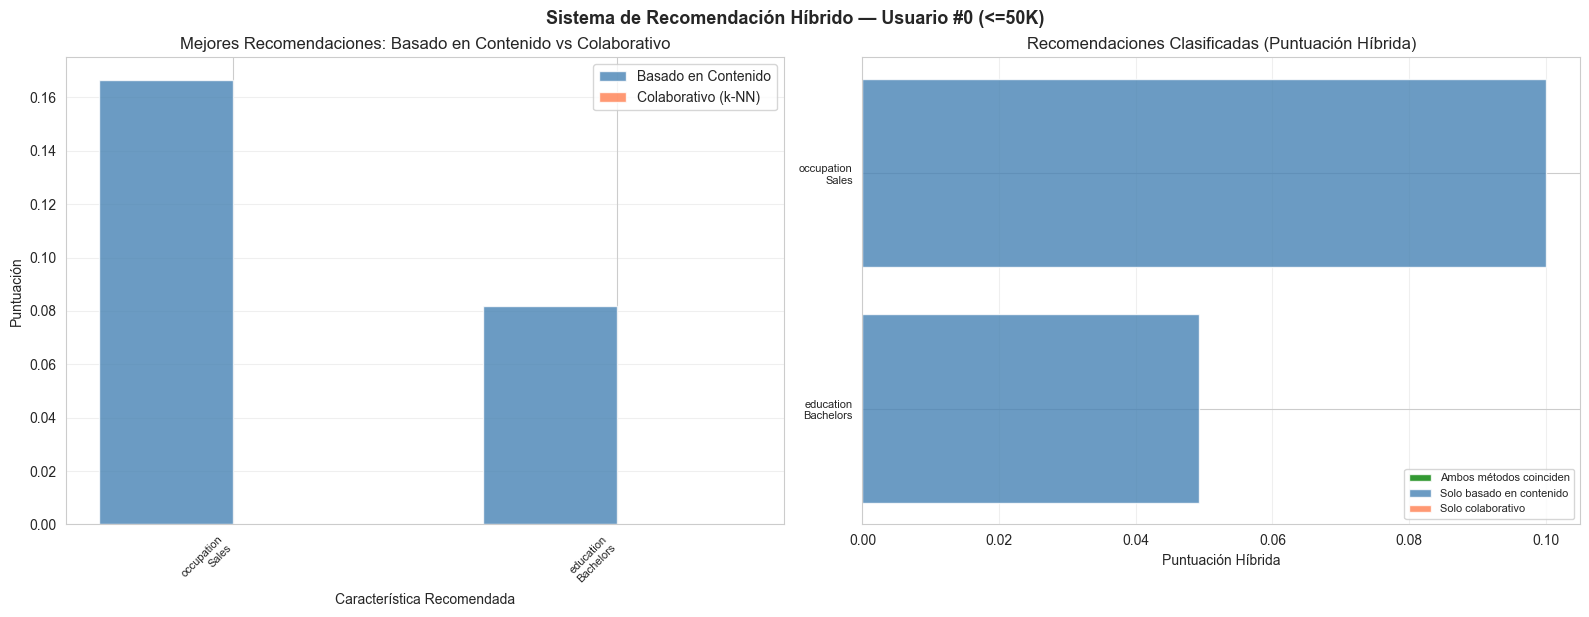

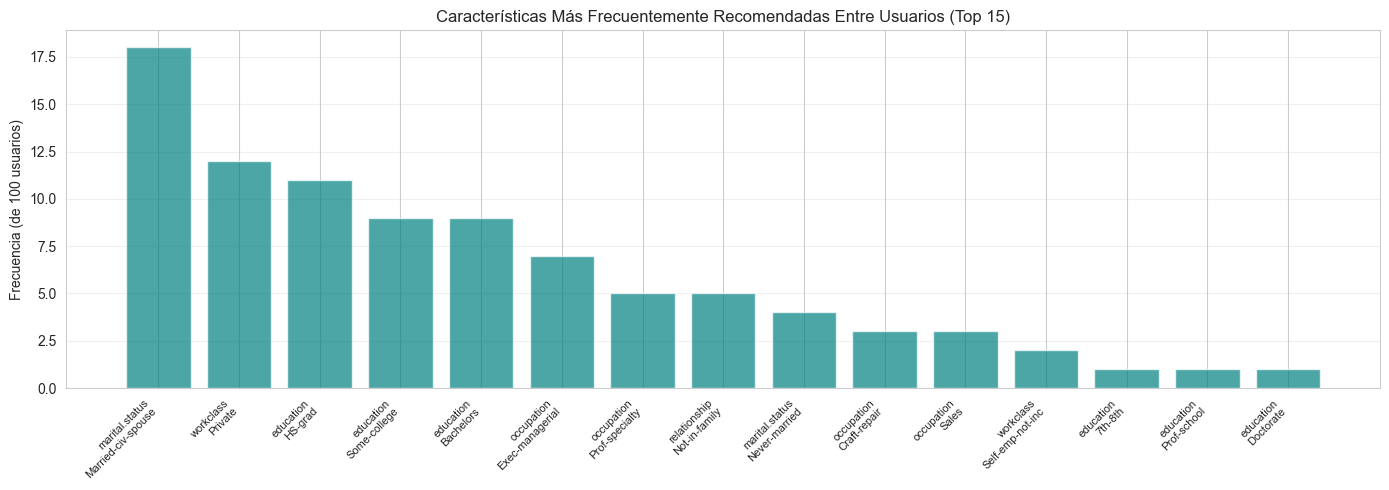

✓ Visualizaciones completadas


In [23]:
## ============================================================
## 4.6 Visualizar Resultados de las Recomendaciones
## ============================================================

# --- Visualizar recomendaciones para el Usuario #0 ---
user = unsuccessful.iloc[0]
recommendations = hybrid_recommend(
    user, successful, knn_model, feature_cols, actionable_encoded_cols,
    top_k_cb=10, n_neighbors_cf=20, weight_cb=0.6, weight_cf=0.4
)

# Filtrar las mejores recomendaciones de adquisición
acquire_recs = [r for r in recommendations if r['type'] == 'acquire'][:10]

# Preparar datos para graficar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Desglose de puntuaciones híbridas ---
features = [r['feature'].replace('_', '\n', 1) for r in acquire_recs[:8]]
cb_scores_plot = [r['cb_score'] for r in acquire_recs[:8]]
cf_scores_plot = [r['cf_score'] for r in acquire_recs[:8]]

x = np.arange(len(features))
width = 0.35

bars1 = axes[0].bar(x - width/2, cb_scores_plot, width, label='Basado en Contenido', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, cf_scores_plot, width, label='Colaborativo (k-NN)', color='coral', alpha=0.8)

axes[0].set_xlabel('Característica Recomendada')
axes[0].set_ylabel('Puntuación')
axes[0].set_title('Mejores Recomendaciones: Basado en Contenido vs Colaborativo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(features, rotation=45, ha='right', fontsize=8)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Gráfico 2: Ranking de puntuación híbrida ---
hybrid_scores = [r['hybrid_score'] for r in acquire_recs[:8]]
sources = [r['source'] for r in acquire_recs[:8]]
colors = ['green' if s == 'ambos' else 'steelblue' if s == 'basado-en-contenido' else 'coral' 
          for s in sources]

axes[1].barh(range(len(features)), hybrid_scores, color=colors, alpha=0.8)
axes[1].set_yticks(range(len(features)))
axes[1].set_yticklabels(features, fontsize=8)
axes[1].set_xlabel('Puntuación Híbrida')
axes[1].set_title('Recomendaciones Clasificadas (Puntuación Híbrida)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Leyenda para colores de fuente
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.8, label='Ambos métodos coinciden'),
                   Patch(facecolor='steelblue', alpha=0.8, label='Solo basado en contenido'),
                   Patch(facecolor='coral', alpha=0.8, label='Solo colaborativo')]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.suptitle('Sistema de Recomendación Híbrido — Usuario #0 (<=50K)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

# --- Gráfico 3: Importancia de características entre todos los usuarios de prueba ---
fig, ax = plt.subplots(figsize=(14, 5))

# Agregar recomendaciones a través de múltiples usuarios
all_recs_counter = Counter()
n_sample_users = min(100, len(unsuccessful))

for i in range(n_sample_users):
    user_i = unsuccessful.iloc[i]
    recs_i = hybrid_recommend(
        user_i, successful, knn_model, feature_cols, actionable_encoded_cols,
        top_k_cb=10, n_neighbors_cf=20
    )
    for r in recs_i:
        if r['type'] == 'acquire' and r['hybrid_score'] > 0.1:
            all_recs_counter[r['feature']] += 1

# Graficar las 15 características más frecuentemente recomendadas
top_features = all_recs_counter.most_common(15)
feat_names = [f[0].replace('_', '\n', 1) for f in top_features]
feat_counts = [f[1] for f in top_features]

ax.bar(range(len(feat_names)), feat_counts, color='teal', alpha=0.7)
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel(f'Frecuencia (de {n_sample_users} usuarios)')
ax.set_title('Características Más Frecuentemente Recomendadas Entre Usuarios (Top 15)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones completadas")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 5: Test with Simulated Cases

We create hypothetical user profiles representing different socioeconomic backgrounds and observe what trajectories (education, occupation, hours, etc.) the recommendation system suggests to improve their estimated income.

### Simulated Profiles:
1. **Maria** — Young woman, HS-grad, service worker, 30 hrs/week, never married
2. **Carlos** — Middle-aged man, Some-college, sales, 40 hrs/week, divorced
3. **Aisha** — Older woman, Bachelors degree, admin-clerical, 35 hrs/week, married

</div>

In [24]:
## ============================================================
## Step 5: Test with Simulated Hypothetical Users
## ============================================================

def build_simulated_user(profile_dict, df_encoded_columns, numerical_cols, scaler):
    """
    Build a simulated user vector compatible with df_encoded structure.
    
    profile_dict should contain:
      - Raw numerical values (age, hours.per.week, etc.)
      - Categorical values as original labels (education='HS-grad', etc.)
    """
    # Initialize all columns to 0
    user_vector = pd.Series(0, index=df_encoded_columns, dtype=float)
    
    # Set numerical features (normalized using the fitted scaler)
    num_feature_names = numerical_cols
    raw_num_values = []
    for col in num_feature_names:
        raw_num_values.append(profile_dict.get(col, 0))
    
    # Transform using the scaler
    normalized = scaler.transform([raw_num_values])[0]
    for i, col in enumerate(num_feature_names):
        user_vector[col] = normalized[i]
    
    # Set categorical features (one-hot encoded columns)
    categorical_mappings = {
        'workclass': profile_dict.get('workclass', ''),
        'education': profile_dict.get('education', ''),
        'marital.status': profile_dict.get('marital.status', ''),
        'occupation': profile_dict.get('occupation', ''),
        'relationship': profile_dict.get('relationship', ''),
        'race': profile_dict.get('race', ''),
        'sex': profile_dict.get('sex', ''),
        'native.country': profile_dict.get('native.country', '')
    }
    
    for var_name, var_value in categorical_mappings.items():
        col_name = f"{var_name}_{var_value}"
        if col_name in user_vector.index:
            user_vector[col_name] = 1
    
    # income_binary = 0 (they earn <=50K, that's why they need recommendations)
    user_vector['income_binary'] = 0
    
    return user_vector


# ============================================================
# Define 3 simulated hypothetical users
# ============================================================

simulated_profiles = {
    "Maria": {
        "description": "25-year-old Hispanic woman, HS-grad, service worker, 30 hrs/week, never married",
        "profile": {
            "age": 25,
            "fnlwgt": 200000,
            "education.num": 9,
            "capital.gain": 0,
            "capital.loss": 0,
            "hours.per.week": 30,
            "workclass": "Private",
            "education": "HS-grad",
            "marital.status": "Never-married",
            "occupation": "Other-service",
            "relationship": "Not-in-family",
            "race": "White",
            "sex": "Female",
            "native.country": "United-States"
        }
    },
    "Carlos": {
        "description": "42-year-old man, Some-college, sales, 40 hrs/week, divorced",
        "profile": {
            "age": 42,
            "fnlwgt": 180000,
            "education.num": 10,
            "capital.gain": 0,
            "capital.loss": 0,
            "hours.per.week": 40,
            "workclass": "Private",
            "education": "Some-college",
            "marital.status": "Divorced",
            "occupation": "Sales",
            "relationship": "Not-in-family",
            "race": "White",
            "sex": "Male",
            "native.country": "United-States"
        }
    },
    "Aisha": {
        "description": "50-year-old woman, Bachelors, admin-clerical, 35 hrs/week, married",
        "profile": {
            "age": 50,
            "fnlwgt": 150000,
            "education.num": 13,
            "capital.gain": 0,
            "capital.loss": 0,
            "hours.per.week": 35,
            "workclass": "Private",
            "education": "Bachelors",
            "marital.status": "Married-civ-spouse",
            "occupation": "Adm-clerical",
            "relationship": "Wife",
            "race": "Black",
            "sex": "Female",
            "native.country": "United-States"
        }
    }
}

# ============================================================
# Run recommendations for each simulated user
# ============================================================

all_simulated_recs = {}

for name, data in simulated_profiles.items():
    print(f"\n{'='*70}")
    print(f"  SIMULATED USER: {name}")
    print(f"  {data['description']}")
    print(f"{'='*70}")
    
    # Build encoded vector
    user_vector = build_simulated_user(
        data['profile'], df_encoded.columns, numerical_cols, scaler
    )
    
    # Run hybrid recommendation
    recommendations = hybrid_recommend(
        user_vector, successful, knn_model, feature_cols, actionable_encoded_cols,
        top_k_cb=10, n_neighbors_cf=20, weight_cb=0.6, weight_cf=0.4
    )
    
    all_simulated_recs[name] = recommendations
    
    # Display results
    acquire_recs = [r for r in recommendations if r['type'] == 'acquire' and r['hybrid_score'] > 0.05]
    drop_recs = [r for r in recommendations if r['type'] == 'drop' and r['hybrid_score'] > 0.05]
    
    print(f"\n  RECOMMENDED TRAJECTORIES TO PURSUE:")
    print(f"  {'Recommendation':<50} {'Score':<8} {'Source':<15}")
    print(f"  {'-'*73}")
    
    for rec in acquire_recs[:10]:
        # Parse feature name into readable format
        feat = rec['feature']
        if '_' in feat:
            parts = feat.split('_', 1)
            readable = f"{parts[0]} → {parts[1].replace('_', ' ')}"
        else:
            readable = feat
        print(f"  {readable:<50} {rec['hybrid_score']:.3f}   {rec['source']}")
    
    if drop_recs:
        print(f"\n  TRAJECTORIES TO RECONSIDER:")
        for rec in drop_recs[:5]:
            feat = rec['feature']
            if '_' in feat:
                parts = feat.split('_', 1)
                readable = f"{parts[0]} → {parts[1].replace('_', ' ')}"
            else:
                readable = feat
            print(f"    ✗ {readable} (score: {rec['hybrid_score']:.3f})")
    
    # Interpret key recommendations
    print(f"\n  INTERPRETATION FOR {name.upper()}:")
    top_3 = acquire_recs[:3]
    for i, rec in enumerate(top_3, 1):
        feat = rec['feature']
        if 'education' in feat:
            print(f"    {i}. Consider pursuing higher education ({feat.split('_',1)[1]})")
        elif 'occupation' in feat:
            print(f"    {i}. Transition to occupation: {feat.split('_',1)[1]}")
        elif 'hours' in feat:
            print(f"    {i}. Increase weekly work hours")
        elif 'marital' in feat:
            print(f"    {i}. Marital status factor: {feat.split('_',1)[1]}")
        elif 'workclass' in feat:
            print(f"    {i}. Consider workclass: {feat.split('_',1)[1]}")
        elif 'relationship' in feat:
            print(f"    {i}. Relationship context: {feat.split('_',1)[1]}")
        else:
            print(f"    {i}. {feat}")

print(f"\n\n{'='*70}")
print("✓ Simulated case testing complete!")
print("  The system provides personalized recommendations based on each user's")
print("  unique profile and the patterns found in successful (>50K) earners.")
print(f"{'='*70}")



  SIMULATED USER: Maria
  25-year-old Hispanic woman, HS-grad, service worker, 30 hrs/week, never married

  RECOMMENDED TRAJECTORIES TO PURSUE:
  Recommendation                                     Score    Source         
  -------------------------------------------------------------------------
  occupation → Sales                                 0.097   basado-en-contenido
  education → Some-college                           0.052   basado-en-contenido
  occupation → Tech-support                          0.052   basado-en-contenido
  education → Assoc-acdm                             0.051   basado-en-contenido

  TRAJECTORIES TO RECONSIDER:
    ✗ occupation → Other-service (score: 0.300)
    ✗ education → HS-grad (score: 0.103)
    ✗ marital.status → Never-married (score: 0.103)

  INTERPRETATION FOR MARIA:
    1. Transition to occupation: Sales
    2. Consider pursuing higher education (Some-college)
    3. Transition to occupation: Tech-support

  SIMULATED USER: Carlos
  42-ye

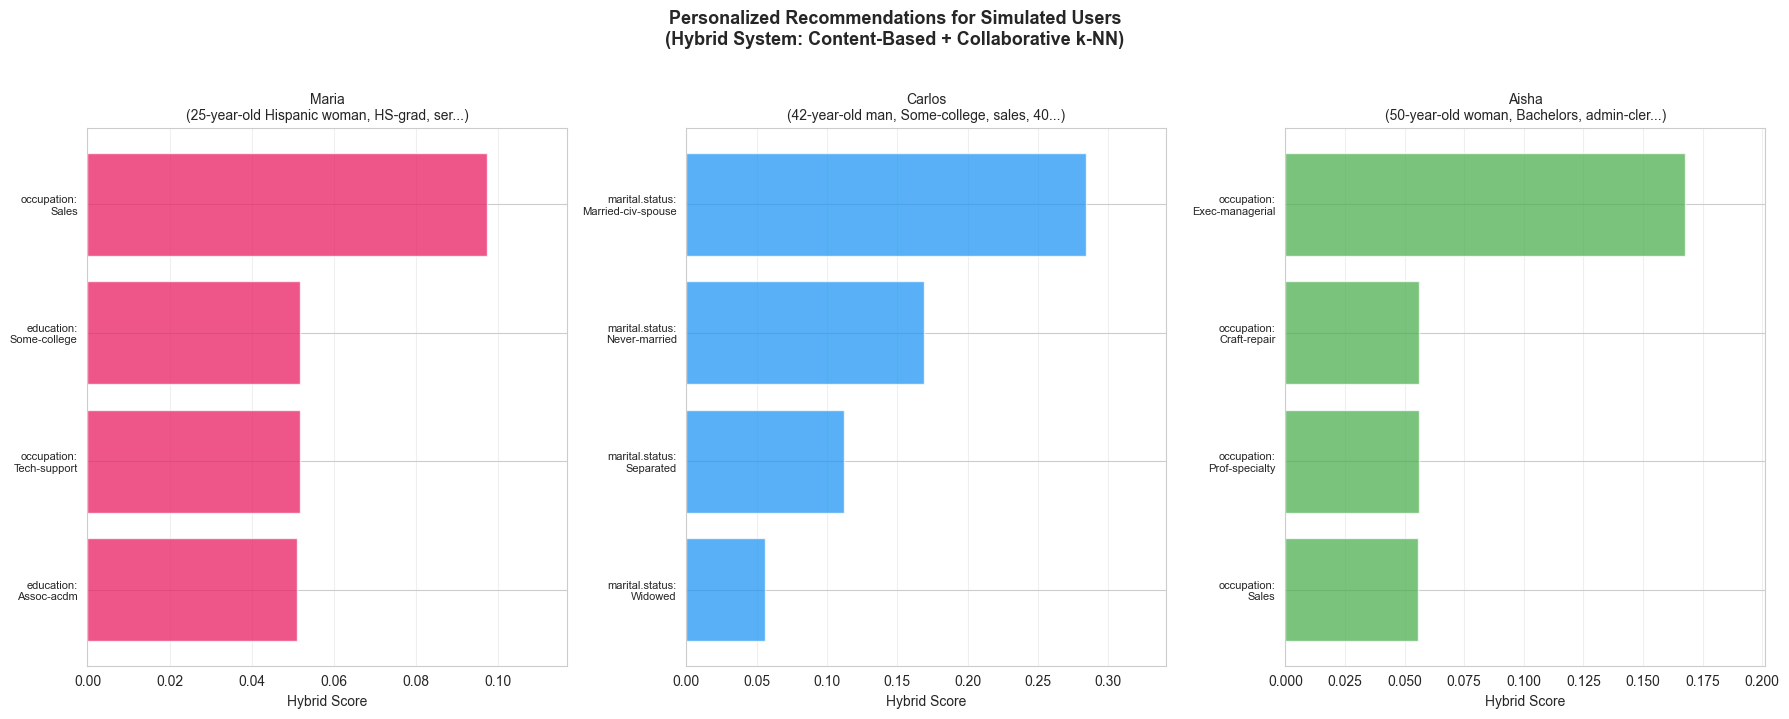


SUMMARY: Key Recommended Trajectories by User

User       Top 1 Recommendation                Top 2 Recommendation                Top 3 Recommendation               
-------------------------------------------------------------------------------------------------------------------
Maria      occupation→Sales                    education→Some-college              occupation→Tech-support            
Carlos     marital.status→Married-civ-spo      marital.status→Never-married        marital.status→Separated           
Aisha      occupation→Exec-managerial          occupation→Craft-repair             occupation→Prof-specialty          

INSIGHT: The system adapts its recommendations to each user's unique context.
  - Maria (young, HS-grad) → likely recommended: higher education + different occupation
  - Carlos (mid-age, some college) → likely recommended: occupation change + more hours
  - Aisha (older, Bachelors) → likely recommended: occupation/relationship trajectory shift


In [25]:
## ============================================================
## 5.2 Visualize Simulated User Recommendations Comparison
## ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)

colors_map = {'Maria': '#E91E63', 'Carlos': '#2196F3', 'Aisha': '#4CAF50'}

for ax, (name, recs) in zip(axes, all_simulated_recs.items()):
    acquire_recs = [r for r in recs if r['type'] == 'acquire' and r['hybrid_score'] > 0.05][:8]
    
    features = []
    scores = []
    for rec in acquire_recs:
        feat = rec['feature']
        if '_' in feat:
            parts = feat.split('_', 1)
            readable = f"{parts[0]}:\n{parts[1].replace('_', ' ')}"
        else:
            readable = feat
        features.append(readable)
        scores.append(rec['hybrid_score'])
    
    bars = ax.barh(range(len(features)), scores, color=colors_map[name], alpha=0.75)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel('Hybrid Score')
    ax.set_title(f'{name}\n({simulated_profiles[name]["description"][:40]}...)', fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, max(scores) * 1.2 if scores else 1)

plt.suptitle('Personalized Recommendations for Simulated Users\n(Hybrid System: Content-Based + Collaborative k-NN)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Summary table comparing key recommendations ---
print("\n" + "="*80)
print("SUMMARY: Key Recommended Trajectories by User")
print("="*80)
print(f"\n{'User':<10} {'Top 1 Recommendation':<35} {'Top 2 Recommendation':<35} {'Top 3 Recommendation':<35}")
print("-"*115)

for name, recs in all_simulated_recs.items():
    top_recs = [r for r in recs if r['type'] == 'acquire'][:3]
    rec_names = []
    for r in top_recs:
        feat = r['feature']
        if '_' in feat:
            readable = f"{feat.split('_',1)[0]}→{feat.split('_',1)[1][:15]}"
        else:
            readable = feat[:20]
        rec_names.append(readable)
    while len(rec_names) < 3:
        rec_names.append("—")
    print(f"{name:<10} {rec_names[0]:<35} {rec_names[1]:<35} {rec_names[2]:<35}")

print("\n" + "="*80)
print("INSIGHT: The system adapts its recommendations to each user's unique context.")
print("  - Maria (young, HS-grad) → likely recommended: higher education + different occupation")
print("  - Carlos (mid-age, some college) → likely recommended: occupation change + more hours")  
print("  - Aisha (older, Bachelors) → likely recommended: occupation/relationship trajectory shift")
print("="*80)
